In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.linear_model import BayesianRidge, LogisticRegression
from sklearn.metrics import (
    accuracy_score, f1_score, mean_absolute_error, mean_squared_error,
    precision_score, recall_score,
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler




In [39]:
# Load the Kaggle Stroke Dataset
data_path = "healthcare-dataset-stroke-data.csv"
df = pd.read_csv(data_path)

# Display the first 5 rows and dataset summary
print("Dataset Shape:", df.shape)
print("\nFirst 5 rows of the dataset:")
df.head()


Dataset Shape: (5110, 12)

First 5 rows of the dataset:


,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


In [40]:
# Display dataset summary
print("\nDataset Summary:")
print(df.info())


Dataset Summary:
<class 'pandas.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   str    
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   str    
 6   work_type          5110 non-null   str    
 7   Residence_type     5110 non-null   str    
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   str    
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), str(5)
memory usage: 479.2 KB
None


In [41]:
# Drop the 'id' column as it carries no predictive value
df_clean = df.drop(columns=['id'])

# Drop initial missing values to obtain a fully intact baseline dataset
df_clean = df_clean.dropna().reset_index(drop=True)

# Encode categorical features into numerical representations
categorical_cols = ['gender', 'ever_married', 'work_type', 'Residence_type', 'smoking_status']
label_encoders = {}

for col in categorical_cols:
    le = LabelEncoder()
    df_clean[col] = le.fit_transform(df_clean[col])
    label_encoders[col] = le

# Display cleaned dataset information
print("Clean Dataset Shape:", df_clean.shape)
print("\nData Types and Missing Values Count:")
print(df_clean.isnull().sum())
print("\nFirst 5 rows of Clean Dataset:")
df_clean.head()

Clean Dataset Shape: (4909, 11)

Data Types and Missing Values Count:
gender               0
age                  0
hypertension         0
heart_disease        0
ever_married         0
work_type            0
Residence_type       0
avg_glucose_level    0
bmi                  0
smoking_status       0
stroke               0
dtype: int64

First 5 rows of Clean Dataset:


,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,1,67.0,0,1,1,2,1,228.69,36.6,1,1
1,1,80.0,0,1,1,2,0,105.92,32.5,2,1
2,0,49.0,0,0,1,2,1,171.23,34.4,3,1
3,0,79.0,1,0,1,3,0,174.12,24.0,2,1
4,1,81.0,0,0,1,2,1,186.21,29.0,1,1


In [42]:
# Separate features (X) and target label (y)
X = df_clean.drop(columns=["stroke"])
y = df_clean["stroke"]

# Split dataset into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Train the Baseline Random Forest Classifier
# Handle class imbalance using class_weight='balanced'
baseline_rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    class_weight="balanced",
    random_state=42
)
baseline_rf.fit(X_train, y_train)

# Predict on the test set and calculate metrics
y_pred_baseline = baseline_rf.predict(X_test)

f1_baseline = f1_score(y_test, y_pred_baseline)
accuracy_baseline = accuracy_score(y_test, y_pred_baseline)
precision_baseline = precision_score(y_test, y_pred_baseline)
recall_baseline = recall_score(y_test, y_pred_baseline)

print("--- Baseline Model Performance (Clean Data) ---")
print(f"Accuracy : {accuracy_baseline:.4f}")
print(f"Precision: {precision_baseline:.4f}")
print(f"Recall   : {recall_baseline:.4f}")
print(f"F1 Score : {f1_baseline:.4f}")

--- Baseline Model Performance (Clean Data) ---
Accuracy : 0.8676
Precision: 0.1271
Recall   : 0.3571
F1 Score : 0.1875


In [43]:

def generate_missing_test_sets(X_test, rates=(0.10, 0.20, 0.30), random_state=42):
    """
    Add missing values to the test set at different rates.
    Missing values from lower rates are kept at higher rates.
    """
    rng = np.random.default_rng(random_state)
    random_values = rng.random(X_test.shape)

    missing_sets = {}
    masks = {}

    for rate in rates:
        label = f"{int(rate * 100)}%"
        mask = random_values < rate

        X_missing = X_test.mask(mask)

        missing_sets[label] = X_missing
        masks[label] = mask

    return missing_sets, masks


missing_rates = [0.10, 0.20, 0.30]

test_missing_sets, test_masks = generate_missing_test_sets(
    X_test, rates=missing_rates, random_state=42
)

print("--- Missing Data Summary ---")

for rate, X_missing in test_missing_sets.items():
    missing_count = X_missing.isna().sum().sum()
    missing_percent = missing_count / X_missing.size * 100

    print(f"{rate}: {missing_count} missing values ({missing_percent:.2f}%)")


--- Missing Data Summary ---
10%: 964 missing values (9.82%)
20%: 1996 missing values (20.33%)
30%: 2985 missing values (30.40%)


In [76]:

NUM_COLS = ["age", "avg_glucose_level", "bmi"]
CAT_COLS = [col for col in X_test.columns if col not in NUM_COLS]



def check_input(X):
    """Validate the input dataset."""
    if not isinstance(X, pd.DataFrame):
        raise TypeError("X must be a pandas DataFrame.")

    expected = NUM_COLS + CAT_COLS

    if set(X.columns) != set(expected):
        raise ValueError("The input has unexpected columns.")

    if X.columns.duplicated().any():
        raise ValueError("Duplicate columns are not allowed.")

    if not X.index.is_unique:
        raise ValueError("The index must be unique.")

    if X.empty:
        raise ValueError("The input dataset is empty.")

    if not all(pd.api.types.is_numeric_dtype(X[col]) for col in X.columns):
        raise TypeError("All features must be numerically encoded.")

    if np.isinf(X.to_numpy(dtype=float)).any():
        raise ValueError("Infinite values are not supported.")

    for col in X.columns:
        if X[col].isna().all():
            raise ValueError(f"All values are missing in '{col}'.")


def initial_fill(X):
    """Initialize missing values using medians and modes."""
    result = X.copy()

    for col in X.columns:
        observed = X[col].dropna()

        if col in NUM_COLS:
            fill_value = observed.median()
        else:
            fill_value = observed.mode().iloc[0]

        result[col] = result[col].fillna(fill_value)

    return result


def prepare_predictors(X_observed, X_missing):
    """Encode categorical predictors and scale numerical predictors."""
    numeric_cols = [
        col for col in X_observed.columns if col in NUM_COLS
    ]
    categorical_cols = [
        col for col in X_observed.columns if col in CAT_COLS
    ]

    transformers = []

    if numeric_cols:
        transformers.append(
            ("numeric", StandardScaler(), numeric_cols)
        )

    if categorical_cols:
        transformers.append(
            (
                "categorical",
                OneHotEncoder(
                    handle_unknown="ignore",
                    sparse_output=False
                ),
                categorical_cols
            )
        )

    preprocessor = ColumnTransformer(
        transformers=transformers
    )

    X_observed_encoded = preprocessor.fit_transform(X_observed)
    X_missing_encoded = preprocessor.transform(X_missing)

    return X_observed_encoded, X_missing_encoded

def calculate_imputation_change(
    old_result,
    new_result,
    missing
):
    """Calculate numerical and categorical iteration changes."""
    numeric_difference = 0.0
    numeric_denominator = 0.0

    for col in NUM_COLS:
        rows = missing[col]

        if not rows.any():
            continue

        old_values = old_result.loc[rows, col].to_numpy(
            dtype=float
        )
        new_values = new_result.loc[rows, col].to_numpy(
            dtype=float
        )

        numeric_difference += np.sum(
            (new_values - old_values) ** 2
        )
        numeric_denominator += np.sum(
            new_values ** 2
        )

    numeric_change = (
        numeric_difference / numeric_denominator
        if numeric_denominator > 0
        else 0.0
    )

    categorical_changes = 0
    categorical_count = 0

    for col in CAT_COLS:
        rows = missing[col]

        categorical_changes += (
            old_result.loc[rows, col]
            != new_result.loc[rows, col]
        ).sum()

        categorical_count += rows.sum()

    categorical_change = (
        categorical_changes / categorical_count
        if categorical_count > 0
        else 0.0
    )

    return numeric_change, categorical_change



In [ ]:
class MixedKNNImputer:
    """Impute mixed-type data using observed-feature KNN distances."""

    def __init__(self, n_neighbors=5):
        self.n_neighbors = n_neighbors

    def fit_transform(self, X):
        check_input(X)

        if not isinstance(self.n_neighbors, int) or self.n_neighbors < 1:
            raise ValueError("n_neighbors must be at least 1.")

        result = X.copy()
        scale = X[NUM_COLS].std().replace(0, 1).fillna(1)

        for idx in X.index:
            row = X.loc[idx]
            missing_cols = row.index[row.isna()]
            observed_cols = row.index[row.notna()]

            for target in missing_cols:
                candidates = X.loc[X[target].notna()]

                if len(observed_cols) == 0:
                    neighbors = candidates[target]
                else:
                    distances = pd.Series(
                        0.0, index=candidates.index
                    )
                    counts = pd.Series(
                        0.0, index=candidates.index
                    )

                    for col in observed_cols:
                        valid = candidates[col].notna()

                        if col in NUM_COLS:
                            difference = (
                                (candidates[col] - row[col])
                                / scale[col]
                            ) ** 2
                        else:
                            difference = (
                                candidates[col] != row[col]
                            ).astype(float)

                        distances += difference.where(valid, 0)
                        counts += valid.astype(float)

                    distances = (
                        distances / counts.replace(0, np.nan)
                    ).dropna()

                    if distances.empty:
                        neighbors = candidates[target]
                    else:
                        neighbor_indices = distances.nsmallest(
                            self.n_neighbors
                        ).index

                        neighbors = candidates.loc[
                            neighbor_indices, target
                        ]

                if target in NUM_COLS:
                    value = neighbors.mean()
                else:
                    value = neighbors.mode().iloc[0]

                result.at[idx, target] = value

        return result
    


In [70]:
# Test the MixedKNNImputer using the 10% missing test dataset
X_missing = test_missing_sets["10%"].copy()

knn_imputer = MixedKNNImputer(n_neighbors=5)
X_imputed = knn_imputer.fit_transform(X_missing)

# Check the number of missing values
print("Missing values before imputation:")
print(X_missing.isna().sum())

print("\nMissing values after imputation:")
print(X_imputed.isna().sum())

# Display the first five rows
print("\nImputed dataset:")
print(X_imputed.head())


# Check whether all missing values have been filled
assert not X_imputed.isna().any().any()

# Check whether observed values remain unchanged
observed_mask = X_missing.notna()

assert np.array_equal(
    X_missing.to_numpy()[observed_mask.to_numpy()],
    X_imputed.to_numpy()[observed_mask.to_numpy()]
)

# Check whether categorical values remain valid
for col in CAT_COLS:
    valid_values = set(X_test[col].unique())
    imputed_values = set(X_imputed[col].unique())

    assert imputed_values.issubset(valid_values), (
        f"Invalid values found in {col}"
    )

print("All KNN validation tests passed.")


Missing values before imputation:
gender               102
age                   99
hypertension          96
heart_disease         89
ever_married         104
work_type            108
Residence_type        83
avg_glucose_level     95
bmi                   88
smoking_status       100
dtype: int64

Missing values after imputation:
gender               0
age                  0
hypertension         0
heart_disease        0
ever_married         0
work_type            0
Residence_type       0
avg_glucose_level    0
bmi                  0
smoking_status       0
dtype: int64

Imputed dataset:
      gender   age  hypertension  heart_disease  ever_married  work_type  \
3845     1.0   9.0           0.0            0.0           0.0        4.0   
2061     0.0  77.0           0.0            0.0           1.0        2.0   
2691     0.0  50.0           0.0            0.0           1.0        2.0   
4568     1.0  46.0           0.0            0.0           1.0        2.0   
1363     1.0  53.0          

In [75]:
# Evaluate KNN imputation at 10%, 20%, and 30% missingness

knn_results = []

for rate in ["10%", "20%", "30%"]:

    # Get the incomplete test dataset
    X_missing = test_missing_sets[rate].copy()

    # Apply KNN imputation
    knn_imputer = MixedKNNImputer(n_neighbors=5)
    X_imputed = knn_imputer.fit_transform(X_missing)

    # Identify artificially missing values
    missing_mask = X_missing.isna()

    # Calculate numerical imputation errors
    num_mask = missing_mask[NUM_COLS].to_numpy()

    true_num = X_test[NUM_COLS].to_numpy()[num_mask]
    imputed_num = X_imputed[NUM_COLS].to_numpy()[num_mask]

    mae = mean_absolute_error(true_num, imputed_num)
    rmse = root_mean_squared_error(true_num, imputed_num)

    # Calculate categorical imputation accuracy
    cat_mask = missing_mask[CAT_COLS].to_numpy()

    true_cat = X_test[CAT_COLS].to_numpy()[cat_mask]
    imputed_cat = X_imputed[CAT_COLS].to_numpy()[cat_mask]

    cat_accuracy = np.mean(true_cat == imputed_cat)

    # Evaluate the existing Random Forest classifier
    y_pred = baseline_rf.predict(X_imputed)
    f1 = f1_score(y_test, y_pred, zero_division=0)

    # Calculate the robustness score
    rq = f1 / f1_baseline if f1_baseline > 0 else np.nan

    # Save the results
    knn_results.append({
        "Missing Rate": rate,
        "MAE": mae,
        "RMSE": rmse,
        "Categorical Accuracy": cat_accuracy,
        "F1-score": f1,
        "Rq": rq
    })

# Display all results in one table
df_knn_results = pd.DataFrame(knn_results)

print("--- KNN Imputation and Robustness Results ---")
print(df_knn_results.to_string(index=False, float_format="%.4f"))


c:\Users\Sam\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
c:\Users\Sam\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
c:\Users\Sam\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
c:\Users\Sam\App

--- KNN Imputation and Robustness Results ---
Missing Rate     MAE    RMSE  Categorical Accuracy  F1-score     Rq
         10% 14.9744 26.2287                0.7082    0.1829 0.9756
         20% 16.9926 27.8392                0.6551    0.1517 0.8092
         30% 18.0521 29.2241                0.6651    0.1333 0.7111


c:\Users\Sam\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
c:\Users\Sam\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
c:\Users\Sam\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
c:\Users\Sam\App

In [ ]:
class MixedMICEImputer:
    """Stochastic chained-equations imputation for mixed-type data."""

    def __init__(
        self,
        max_iter=10,
        random_state=42
    ):
        self.max_iter = max_iter
        self.random_state = random_state

    def fit_transform(self, X):
        check_input(X)

        rng = np.random.default_rng(self.random_state)
        missing = X.isna()
        result = initial_fill(X)

        target_cols = [
            col for col in X.columns if missing[col].any()
        ]

        for iteration in range(self.max_iter):
            for col in target_cols:
                observed_rows = ~missing[col]
                missing_rows = missing[col]

                predictors = result.drop(columns=col)

                X_observed = predictors.loc[observed_rows]
                X_missing = predictors.loc[missing_rows]

                y_observed = X.loc[observed_rows, col]

                X_observed, X_missing = prepare_predictors(
                    X_observed,
                    X_missing
                )

                if col in NUM_COLS:
                    model = BayesianRidge()
                    model.fit(X_observed, y_observed)

                    mean, std = model.predict(
                        X_missing,
                        return_std=True
                    )

                    predictions = rng.normal(mean, std)

                else:
                    if y_observed.nunique() == 1:
                        predictions = np.repeat(
                            y_observed.iloc[0],
                            missing_rows.sum()
                        )
                    else:
                        model = LogisticRegression(
                            max_iter=2000
                        )

                        model.fit(X_observed, y_observed)

                        probabilities = model.predict_proba(
                            X_missing
                        )

                        predictions = [
                            rng.choice(
                                model.classes_,
                                p=probabilities[i]
                            )
                            for i in range(len(probabilities))
                        ]

                result.loc[missing_rows, col] = predictions

        return result


In [ ]:

class MixedMissForestImputer:
    """Iterative mixed-type random forest imputation."""

    def __init__(
        self,
        max_iter=10,
        n_estimators=100,
        random_state=42
    ):
        self.max_iter = max_iter
        self.n_estimators = n_estimators
        self.random_state = random_state

    def fit_transform(self, X):
        check_input(X)

        missing = X.isna()
        result = initial_fill(X)

        target_cols = [
            col for col in X.columns if missing[col].any()
        ]

        target_cols.sort(
            key=lambda col: missing[col].sum()
        )

        previous_change = None
        previous_result = result.copy()

        has_numeric_missing = any(
            missing[col].any() for col in NUM_COLS
        )
        has_categorical_missing = any(
            missing[col].any() for col in CAT_COLS
        )

        for iteration in range(self.max_iter):
            old_result = result.copy()

            for col in target_cols:
                observed_rows = ~missing[col]
                missing_rows = missing[col]

                predictors = result.drop(columns=col)

                X_observed = predictors.loc[observed_rows]
                X_missing = predictors.loc[missing_rows]
                y_observed = X.loc[observed_rows, col]

                if col in NUM_COLS:
                    model = RandomForestRegressor(
                        n_estimators=self.n_estimators,
                        random_state=self.random_state,
                        n_jobs=-1
                    )
                else:
                    if y_observed.nunique() == 1:
                        result.loc[missing_rows, col] = (
                            y_observed.iloc[0]
                        )
                        continue

                    model = RandomForestClassifier(
                        n_estimators=self.n_estimators,
                        random_state=self.random_state,
                        n_jobs=-1
                    )

                model.fit(X_observed, y_observed)

                predictions = model.predict(X_missing)

                result.loc[missing_rows, col] = predictions

            current_change = calculate_imputation_change(
                old_result,
                result,
                missing
            )

            if previous_change is not None:
                numeric_worse = (
                    has_numeric_missing
                    and current_change[0] > previous_change[0]
                )

                categorical_worse = (
                    has_categorical_missing
                    and current_change[1] > previous_change[1]
                )

                if numeric_worse or categorical_worse:
                    result = previous_result.copy()
                    break

            previous_change = current_change
            previous_result = result.copy()

        return result


In [64]:

# Store the evaluation results
imputation_results = []
robustness_results = []

for rate, methods in imputed_datasets.items():
    mask = test_masks[rate]

    # Separate missing positions for numerical and categorical features
    mask_df = pd.DataFrame(
        mask,
        columns=X_test.columns,
        index=X_test.index
    )

    for method_name, X_imputed in methods.items():

        # Evaluate numerical imputation
        true_num = X_test[NUM_COLS].to_numpy()
        imputed_num = X_imputed[NUM_COLS].to_numpy()
        num_mask = mask_df[NUM_COLS].to_numpy()

        mae = mean_absolute_error(
            true_num[num_mask],
            imputed_num[num_mask]
        )

        rmse = root_mean_squared_error(
            true_num[num_mask],
            imputed_num[num_mask]
        )

        # Evaluate categorical imputation
        true_cat = X_test[CAT_COLS].to_numpy()
        imputed_cat = X_imputed[CAT_COLS].to_numpy()
        cat_mask = mask_df[CAT_COLS].to_numpy()

        cat_accuracy = np.mean(
            true_cat[cat_mask] == imputed_cat[cat_mask]
        )

        imputation_results.append({
            "Missing Rate": rate,
            "Method": method_name,
            "MAE": mae,
            "RMSE": rmse,
            "Categorical Accuracy": cat_accuracy
        })

        # Evaluate the same trained Random Forest
        y_pred = baseline_rf.predict(X_imputed)

        accuracy = accuracy_score(y_test, y_pred)
        precision = precision_score(y_test, y_pred, zero_division=0)
        recall = recall_score(y_test, y_pred, zero_division=0)
        f1 = f1_score(y_test, y_pred, zero_division=0)

        # Calculate robustness relative to the clean baseline
        rq = f1 / f1_baseline if f1_baseline > 0 else np.nan

        robustness_results.append({
            "Missing Rate": rate,
            "Method": method_name,
            "Accuracy": accuracy,
            "Precision": precision,
            "Recall": recall,
            "F1 Score": f1,
            "Robustness Score (Rq)": rq
        })


# Convert results to DataFrames
df_imp_metrics = pd.DataFrame(imputation_results)
df_rob_metrics = pd.DataFrame(robustness_results)

print("--- Imputation Accuracy ---")
print(df_imp_metrics.to_string(index=False))

print("\n--- Model Robustness ---")
print(df_rob_metrics.to_string(index=False))


--- Imputation Accuracy ---
Missing Rate          Method       MAE      RMSE  Categorical Accuracy
         10%             KNN 16.218121 26.925611              0.683284
         10%            MICE 14.712160 23.895156              0.740469
         10% MissForest-like 14.661300 23.472008              0.714076
         20%             KNN 16.263256 26.883342              0.693420
         20%            MICE 15.143685 24.303471              0.727404
         20% MissForest-like 15.788946 25.685254              0.702820
         30%             KNN 16.919526 28.396206              0.680943
         30%            MICE 15.788767 25.723544              0.711742
         30% MissForest-like 16.337726 27.303624              0.690087

--- Model Robustness ---
Missing Rate          Method  Accuracy  Precision   Recall  F1 Score  Robustness Score (Rq)
         10%             KNN  0.861507   0.114754 0.333333  0.170732               0.910569
         10%            MICE  0.857434   0.117188 0.

c:\Users\Sam\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
c:\Users\Sam\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
c:\Users\Sam\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
c:\Users\Sam\App

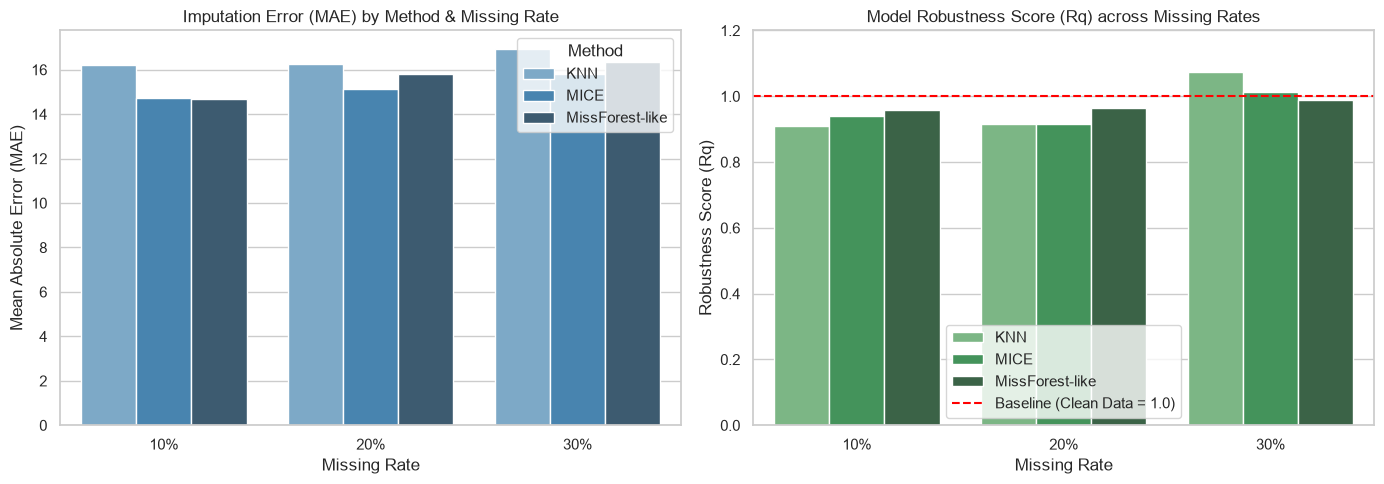

Chart saved successfully as 'imputation_robustness_results.png'!


In [47]:
# Set visual style
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Imputation Precision (MAE across Missing Rates)
sns.barplot(
    data=df_imp_metrics,
    x="Missing Rate",
    y="MAE",
    hue="Method",
    ax=axes[0],
    palette="Blues_d",
)
axes[0].set_title("Imputation Error (MAE) by Method & Missing Rate")
axes[0].set_ylabel("Mean Absolute Error (MAE)")

# Plot 2: Downstream Classifier Robustness (Rq Score)
sns.barplot(
    data=df_rob_metrics,
    x="Missing Rate",
    y="Robustness Score (Rq)",
    hue="Method",
    ax=axes[1],
    palette="Greens_d",
)
axes[1].axhline(
    1.0, color="red", linestyle="--", label="Baseline (Clean Data = 1.0)"
)
axes[1].set_title("Model Robustness Score (Rq) across Missing Rates")
axes[1].set_ylabel("Robustness Score (Rq)")
axes[1].set_ylim(0, 1.2)
axes[1].legend()

plt.tight_layout()
plt.savefig("imputation_robustness_results.png", dpi=300)
plt.show()

print("Chart saved successfully as 'imputation_robustness_results.png'!")